In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [46]:
df=pd.read_csv("/workspaces/Aress_Task/data/Preprocessed_titanic.csv")

In [47]:
df.head()

,survived,pclass,sex,age,fare,family_size,embarked_C,embarked_Q,embarked_S
0,0.0,3.0,1.0,22.0,725.00,2.0,0.0,0.0,1.0
1,1.0,1.0,0.0,38.0,7128.33,2.0,1.0,0.0,0.0
2,1.0,3.0,0.0,26.0,792.50,1.0,0.0,0.0,1.0
3,1.0,1.0,0.0,35.0,5310.00,2.0,0.0,0.0,1.0
4,0.0,3.0,1.0,35.0,805.00,1.0,0.0,0.0,1.0


In [48]:
df=df.dropna()

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     679 non-null    float64
 1   pclass       679 non-null    float64
 2   sex          679 non-null    float64
 3   age          679 non-null    float64
 4   fare         679 non-null    float64
 5   family_size  679 non-null    float64
 6   embarked_C   679 non-null    float64
 7   embarked_Q   679 non-null    float64
 8   embarked_S   679 non-null    float64
dtypes: float64(9)
memory usage: 47.9 KB


In [50]:
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import StandardScaler

In [51]:
X=df.drop(['survived'],axis=1)
y=df['survived']

In [52]:
y.isnull().sum()

np.int64(0)

In [53]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


In [54]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [55]:
from xgboost import XGBClassifier 

In [56]:
xg_model=XGBClassifier()
xg_model.fit(X_train,y_train)
y_pred=xg_model.predict(X_test)

In [57]:
from sklearn.metrics import confusion_matrix,roc_auc_score,classification_report
import seaborn as sns

Report of  XG Boost
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        80
         1.0       0.79      0.73      0.76        56

    accuracy                           0.81       136
   macro avg       0.80      0.80      0.80       136
weighted avg       0.81      0.81      0.81       136

ROC-AUC: 0.8587053571428571
Confusion Matrix


Text(50.722222222222214, 0.5, 'Predicted')

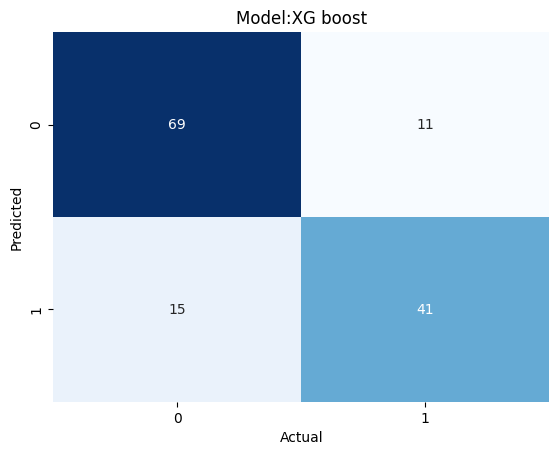

In [58]:
print("Report of  XG Boost")
y_prob = xg_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Model:XG boost")    
plt.xlabel("Actual")
plt.ylabel('Predicted')

In [59]:
from catboost import CatBoostClassifier
cat_model=CatBoostClassifier()
cat_model.fit(X_train,y_train)
y_pred=cat_model.predict(X_test)

Learning rate set to 0.007938
0:	learn: 0.6879005	total: 2.48ms	remaining: 2.47s
1:	learn: 0.6840698	total: 3.52ms	remaining: 1.76s
2:	learn: 0.6796271	total: 4.33ms	remaining: 1.44s
3:	learn: 0.6755698	total: 5.11ms	remaining: 1.27s
4:	learn: 0.6713696	total: 6.06ms	remaining: 1.21s
5:	learn: 0.6675102	total: 8.3ms	remaining: 1.37s
6:	learn: 0.6630496	total: 9.06ms	remaining: 1.28s
7:	learn: 0.6590435	total: 9.74ms	remaining: 1.21s
8:	learn: 0.6551689	total: 10.3ms	remaining: 1.13s
9:	learn: 0.6516327	total: 11.1ms	remaining: 1.1s
10:	learn: 0.6495448	total: 11.5ms	remaining: 1.03s
11:	learn: 0.6466814	total: 12ms	remaining: 984ms
12:	learn: 0.6435299	total: 12.4ms	remaining: 940ms
13:	learn: 0.6397606	total: 13.1ms	remaining: 921ms
14:	learn: 0.6364341	total: 13.7ms	remaining: 903ms
15:	learn: 0.6326040	total: 14.5ms	remaining: 892ms
16:	learn: 0.6292569	total: 15.3ms	remaining: 883ms
17:	learn: 0.6257032	total: 16ms	remaining: 874ms
18:	learn: 0.6220493	total: 16.8ms	remaining: 866m

Report of  CatBoost
              precision    recall  f1-score   support

         0.0       0.82      0.94      0.88        80
         1.0       0.89      0.71      0.79        56

    accuracy                           0.85       136
   macro avg       0.86      0.83      0.83       136
weighted avg       0.85      0.85      0.84       136

ROC-AUC: 0.8629464285714286
Confusion Matrix


Text(50.722222222222214, 0.5, 'Predicted')

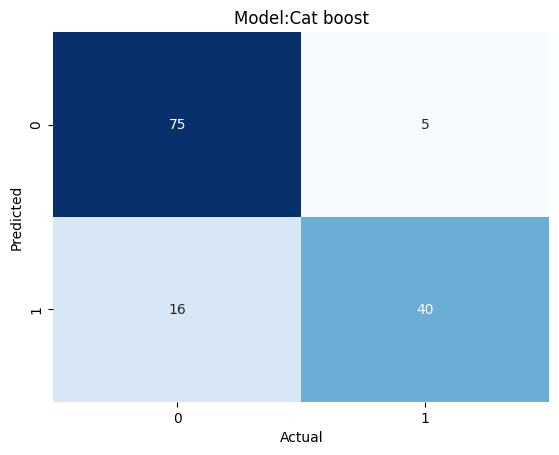

In [60]:
print("Report of  CatBoost")
y_prob = cat_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Model:Cat boost")    
plt.xlabel("Actual")
plt.ylabel('Predicted')

In [61]:
from lightgbm import LGBMClassifier
lgbm_model=LGBMClassifier()
lgbm_model.fit(X_train,y_train)
y_pred=lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 223, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 190
[LightGBM] [Info] Number of data points in the train set: 543, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.410681 -> initscore=-0.361149
[LightGBM] [Info] Start training from score -0.361149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Report of  LightGBM
              precision    recall  f1-score   support

         0.0       0.85      0.90      0.87        80
         1.0       0.84      0.77      0.80        56

    accuracy                           0.85       136
   macro avg       0.85      0.83      0.84       136
weighted avg       0.85      0.85      0.84       136

ROC-AUC: 0.8629464285714286
Confusion Matrix


Text(50.722222222222214, 0.5, 'Predicted')

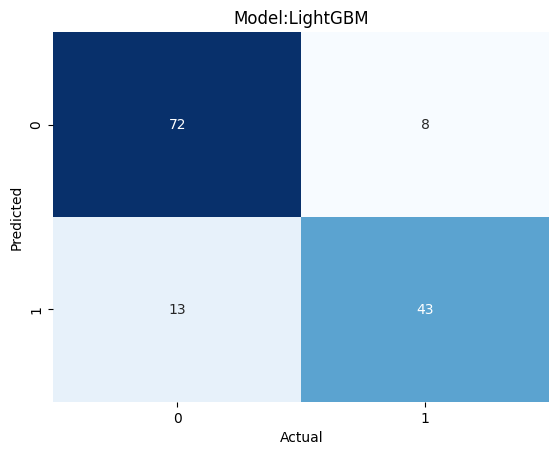

In [62]:
print("Report of  LightGBM")
y_prob = cat_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Model:LightGBM")    
plt.xlabel("Actual")
plt.ylabel('Predicted')

**Stacking**

In [63]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [65]:
estimators=[
   ('lgbm_model',LGBMClassifier()),
   ( 'xg_model',XGBClassifier()),
   ('cat_model',CatBoostClassifier())
]

stack_model=StackingClassifier(
   estimators=estimators,
   final_estimator=LogisticRegression(),
   cv=5
)

stack_model.fit(X_train,y_train)
y_pred=stack_model.predict(X_test)


[LightGBM] [Info] Number of positive: 223, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 190
[LightGBM] [Info] Number of data points in the train set: 543, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.410681 -> initscore=-0.361149
[LightGBM] [Info] Start training from score -0.361149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

Learning rate set to 0.007213
0:	learn: 0.6880053	total: 1.56ms	remaining: 1.56s
1:	learn: 0.6846394	total: 2.45ms	remaining: 1.22s
2:	learn: 0.6809133	total: 2.99ms	remaining: 994ms
3:	learn: 0.6775393	total: 3.62ms	remaining: 901ms
4:	learn: 0.6733298	total: 4.24ms	remaining: 844ms
5:	learn: 0.6711730	total: 4.68ms	remaining: 775ms
6:	learn: 0.6665062	total: 5.41ms	remaining: 767ms
7:	learn: 0.6627084	total: 6.15ms	remaining: 763ms
8:	learn: 0.6587788	total: 6.73ms	remaining: 741ms
9:	learn: 0.6546668	total: 7.52ms	remaining: 744ms
10:	learn: 0.6509058	total: 8.28ms	remaining: 745ms
11:	learn: 0.6470055	total: 8.93ms	remaining: 736ms
12:	learn: 0.6437049	total: 9.44ms	remaining: 717ms
13:	learn: 0.6395699	total: 10.1ms	remaining: 713ms
14:	learn: 0.6355558	total: 10.8ms	remaining: 709ms
15:	learn: 0.6324492	total: 11.5ms	remaining: 706ms
16:	learn: 0.6286038	total: 12.3ms	remaining: 709ms
17:	learn: 0.6242433	total: 13ms	remaining: 707ms
18:	learn: 0.6207302	total: 13.6ms	remaining: 

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Report of  Stacking
              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        80
         1.0       0.89      0.73      0.80        56

    accuracy                           0.85       136
   macro avg       0.86      0.83      0.84       136
weighted avg       0.86      0.85      0.85       136

ROC-AUC: 0.8629464285714286
Confusion Matrix


Text(50.722222222222214, 0.5, 'Predicted')

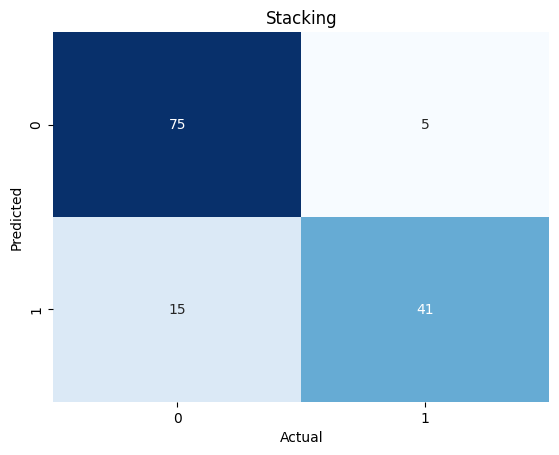

In [66]:
print("Report of  Stacking")
y_prob = cat_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Stacking")    
plt.xlabel("Actual")
plt.ylabel('Predicted')